In [1]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr

import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution
jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Generate samples from a Gaussian mixture

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 1000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [0.5, 0.0],   # mean of first Gaussian
    [-0.5, 0.0],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])

# Generate samples
samples = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal distributions

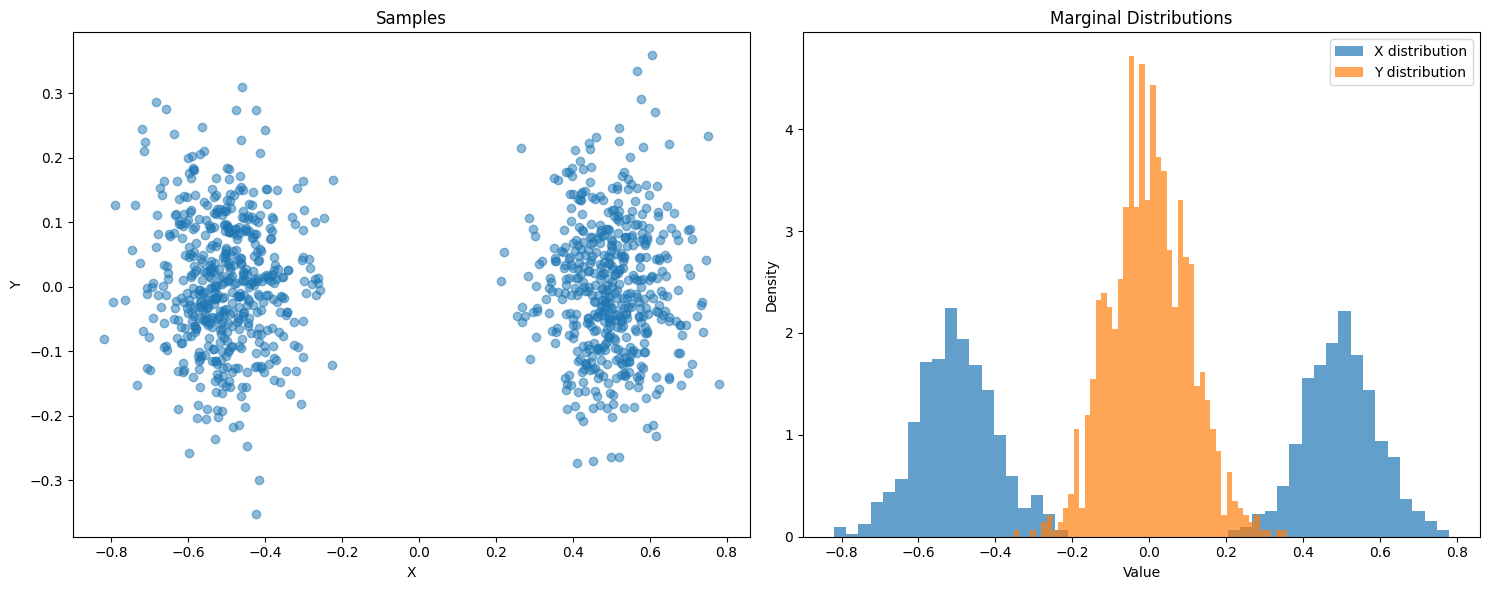

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# First subplot: Scatter plot of samples
ax1.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')
ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [4]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )

k_b = 1.0
T = .1
def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=k_b, T=T):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [5]:
N_osc = 2

k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 1.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

### Bringe energy into correct form

In [6]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


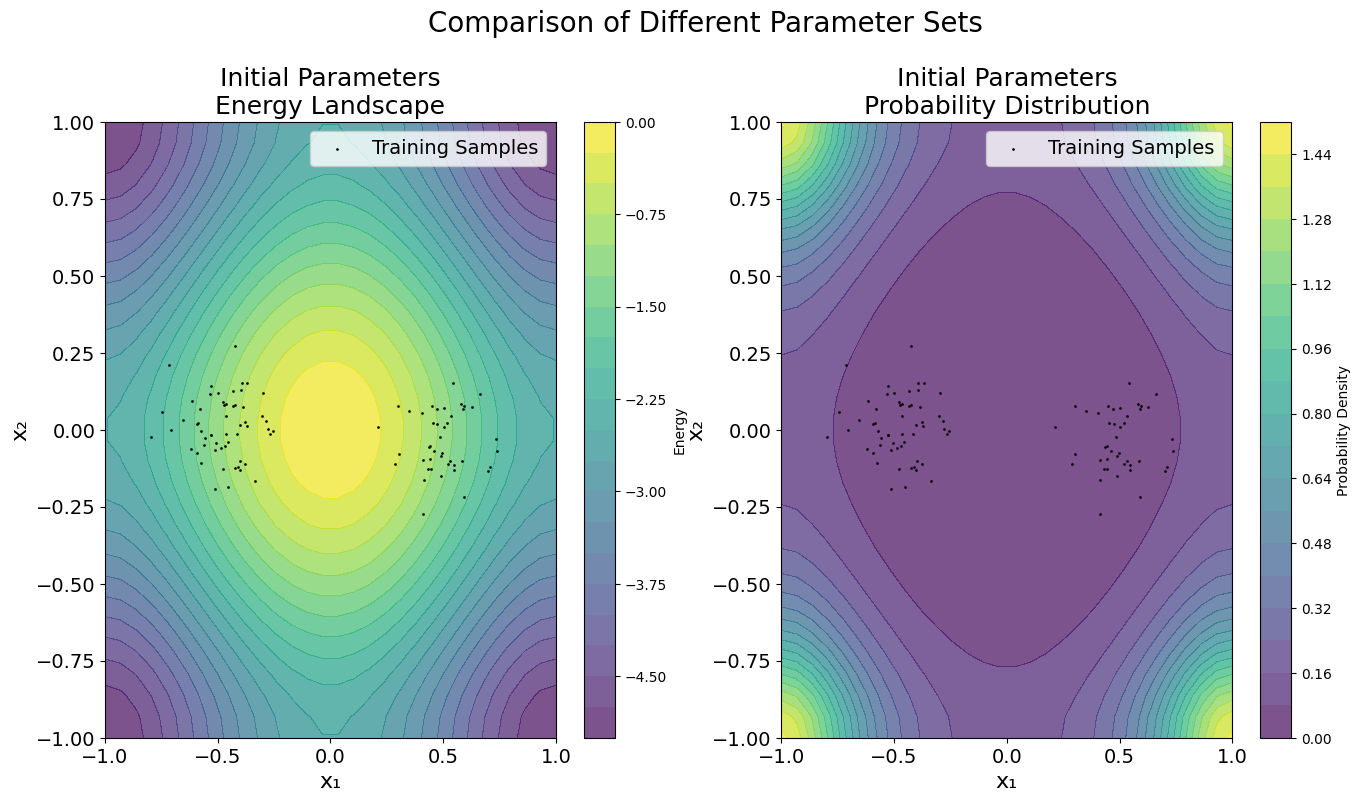

In [7]:
# Example usage:
param_list = [flattened_args_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples,
    x1_range=(-1, 1),    # optional
    x2_range=(-1, 1),    # optional
    n_points=30,        # optional
    titles=titles,       # optional
    figsize=(16, 8),    # optional
    fontsize=16,         # optional
    suptitle="Comparison of Different Parameter Sets"  # optional
)

### Score Matching

In [8]:
learning_rate = 0.01
n_epochs = 4000
batch_size = 128
loss_per_batch = setup_score_matching_loss_per_batch(energy_fn)
params_history, loss_history = run_optimization(loss_per_batch, flattened_args_initial, samples, gradient_fn_per_batch = None, key=key,batch_size=batch_size, learning_rate=learning_rate, n_epochs=n_epochs)

Epoch 0
params:
[-0.99 -0.99  1.01  1.01  0.01  0.01]
Loss: 18.7268
---
Epoch 100
params:
[-0.58550618 -0.01874708  1.76492432  1.97391669  0.20195187 -0.05047805]
Loss: -11.7155
---
Epoch 200
params:
[-0.60247595  0.91913513  2.47175589  2.90203403  0.14361264 -0.03593055]
Loss: -24.2055
---
Epoch 300
params:
[-0.77470708  1.80916977  3.19951952  3.77317643  0.10672282 -0.08389885]
Loss: -34.6832
---
Epoch 400
params:
[-0.95724883  2.64566245  3.9575374   4.59516316  0.09373543 -0.027513  ]
Loss: -41.7199
---
Epoch 500
params:
[-1.15127987  3.43355782  4.71778944  5.36334455  0.08020881 -0.080304  ]
Loss: -52.4340
---
Epoch 600
params:
[-1.35467773  4.16811509  5.4697614   6.06596147  0.06615923 -0.07388545]
Loss: -58.3221
---
Epoch 700
params:
[-1.53087874  4.8455927   6.19633312  6.69970314  0.03231094 -0.15558487]
Loss: -62.5945
---
Epoch 800
params:
[-1.74218542  5.46408879  6.89517713  7.27629743  0.02747231 -0.03983072]
Loss: -67.9202
---
Epoch 900
params:
[-1.92367558  6.041374

Best loss: -1.1160e+02
Found at epoch: 3090


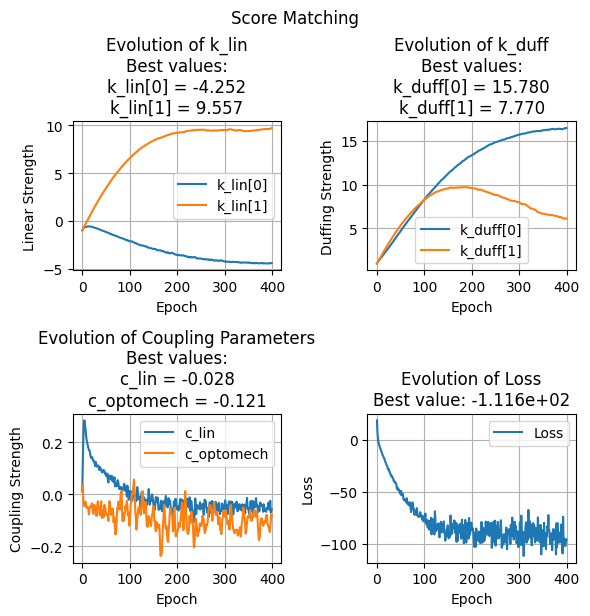

In [9]:
# For the first optimization
k_lin_best, k_duff_best, c_lin_best, c_optomech_best = plot_parameter_evolution(
    params_history=params_history,
    loss_history=loss_history,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=10,
    title="Score Matching"
)
args_best_sm = (k_lin_best, k_duff_best, c_lin_best, c_optomech_best)
flattened_args_best_sm, _ = flatten_util.ravel_pytree(args_best_sm)


### Contrastive Divergence 1

In [10]:
# Define optimization parameters
learning_rate = learning_rate
n_epochs = n_epochs
batch_size = batch_size
loss_per_batch = setup_score_matching_loss_per_batch(energy_fn)
key, subkey = jr.split(key)
cd1_grad = lambda params, batch: -CD1_gradient(energy_fn, batch, params, 
                            dt=0.001, D=1, key=subkey, num_noise_samples=100)

params_history_cd1, loss_history_cd1 = run_optimization(loss_per_batch, flattened_args_initial, samples, gradient_fn_per_batch = cd1_grad, key=key,batch_size=batch_size, learning_rate=learning_rate, n_epochs=n_epochs)

Epoch 0
params:
[-0.99 -0.99  1.01  1.01  0.01  0.01]
Loss: 18.9070
---
Epoch 100
params:
[-0.5987332  -0.02166392  1.75396656  1.97016832  0.2085148   0.19104425]
Loss: -11.4619
---
Epoch 200
params:
[-0.60622654  0.914918    2.44628315  2.89116755  0.14959101  0.20295285]
Loss: -22.4999
---
Epoch 300
params:
[-0.74823593  1.80080173  3.16383924  3.77740123  0.10665308  0.18351294]
Loss: -33.9368
---
Epoch 400
params:
[-0.93436824  2.63818703  3.88970114  4.58884942  0.11902146  0.19031573]
Loss: -41.5961
---
Epoch 500
params:
[-1.11368641  3.41995202  4.61959346  5.34473077  0.09589639  0.20671665]
Loss: -49.0000
---
Epoch 600
params:
[-1.32215307  4.14511861  5.33656424  6.02776061  0.07167778  0.18634317]
Loss: -60.7156
---
Epoch 700
params:
[-1.5136295   4.8316083   6.05504024  6.65623075  0.056062    0.16020224]
Loss: -63.1659
---
Epoch 800
params:
[-1.68550625  5.462841    6.74242782  7.22537925  0.03771911  0.11611803]
Loss: -67.2193
---
Epoch 900
params:
[-1.82094471  6.048189

Best loss: -1.1318e+02
Found at epoch: 2630


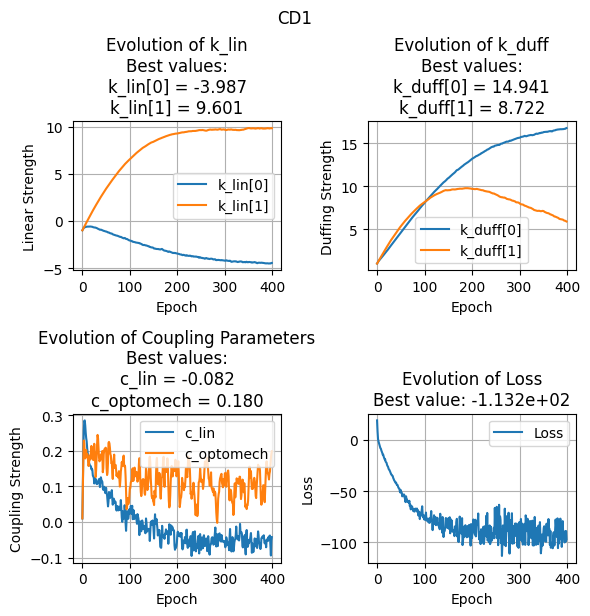

In [11]:
# For the CD1 optimization
k_lin_best_cd1, k_duff_best_cd1, c_lin_best_cd1, c_optomech_best_cd1 = plot_parameter_evolution(
    params_history=params_history_cd1,
    loss_history=loss_history_cd1,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=10,
    title="CD1"
)
args_best_cd1 = (k_lin_best_cd1, k_duff_best_cd1, c_lin_best_cd1, c_optomech_best_cd1)
flattened_args_best_cd1, _ = flatten_util.ravel_pytree(args_best_cd1)


### MLE

In [12]:
# Define optimization parameters
learning_rate = 1.
n_epochs = 40
batch_size = samples.shape[0]//2

loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn, N_osc, gamma=1.0, k_b=1.0, T=1.0, t0=0.0, t1=10.0, N_samples=1000, dt0=0.01, initial_state=jnp.array([0.,0.]))

params_history_mle, loss_history_mle = run_optimization(loss_fn_per_batch, flattened_args_initial, samples, gradient_fn_per_batch = gradient_fn_per_batch, key=key,batch_size=batch_size, learning_rate=learning_rate, n_epochs=n_epochs, maximize=True)

/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

Epoch 0
params:
[-3.24154892e-09 -2.47991883e-09  2.00000000e+00  2.00000000e+00
  9.99999988e-01  9.99999997e-01]
Loss: 594.0263
---


Best loss: 1.1014e+03
Found at epoch: 34


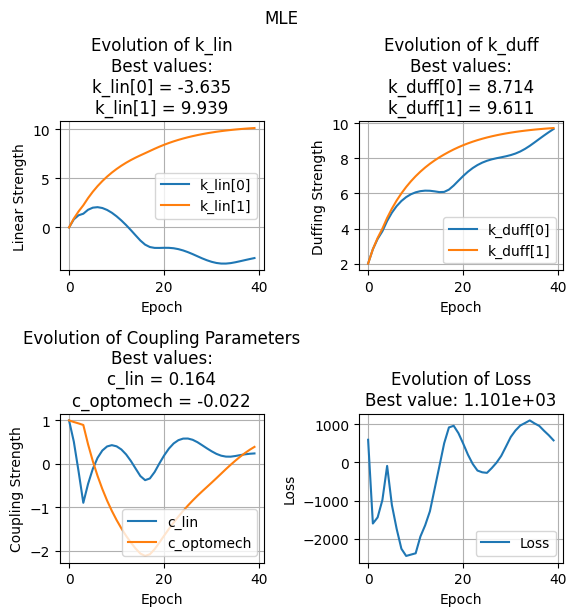

In [13]:
# For the CD1 optimization
k_lin_best_mle, k_duff_best_mle, c_lin_best_mle, c_optomech_best_mle = plot_parameter_evolution(
    params_history=params_history_mle,
    loss_history=loss_history_mle,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=1,
    title="MLE",
    maximize=True
)
args_best_mle = (k_lin_best_mle, k_duff_best_mle, c_lin_best_mle, c_optomech_best_mle)
flattened_args_best_mle, _ = flatten_util.ravel_pytree(args_best_mle)

### Compare solutions

Initial Parameters probability distribution total (should be ≈ 1): 1.000000
Score Matching Best probability distribution total (should be ≈ 1): 1.000000
CD-1 Best probability distribution total (should be ≈ 1): 1.000000
MLE Best probability distribution total (should be ≈ 1): 1.000000


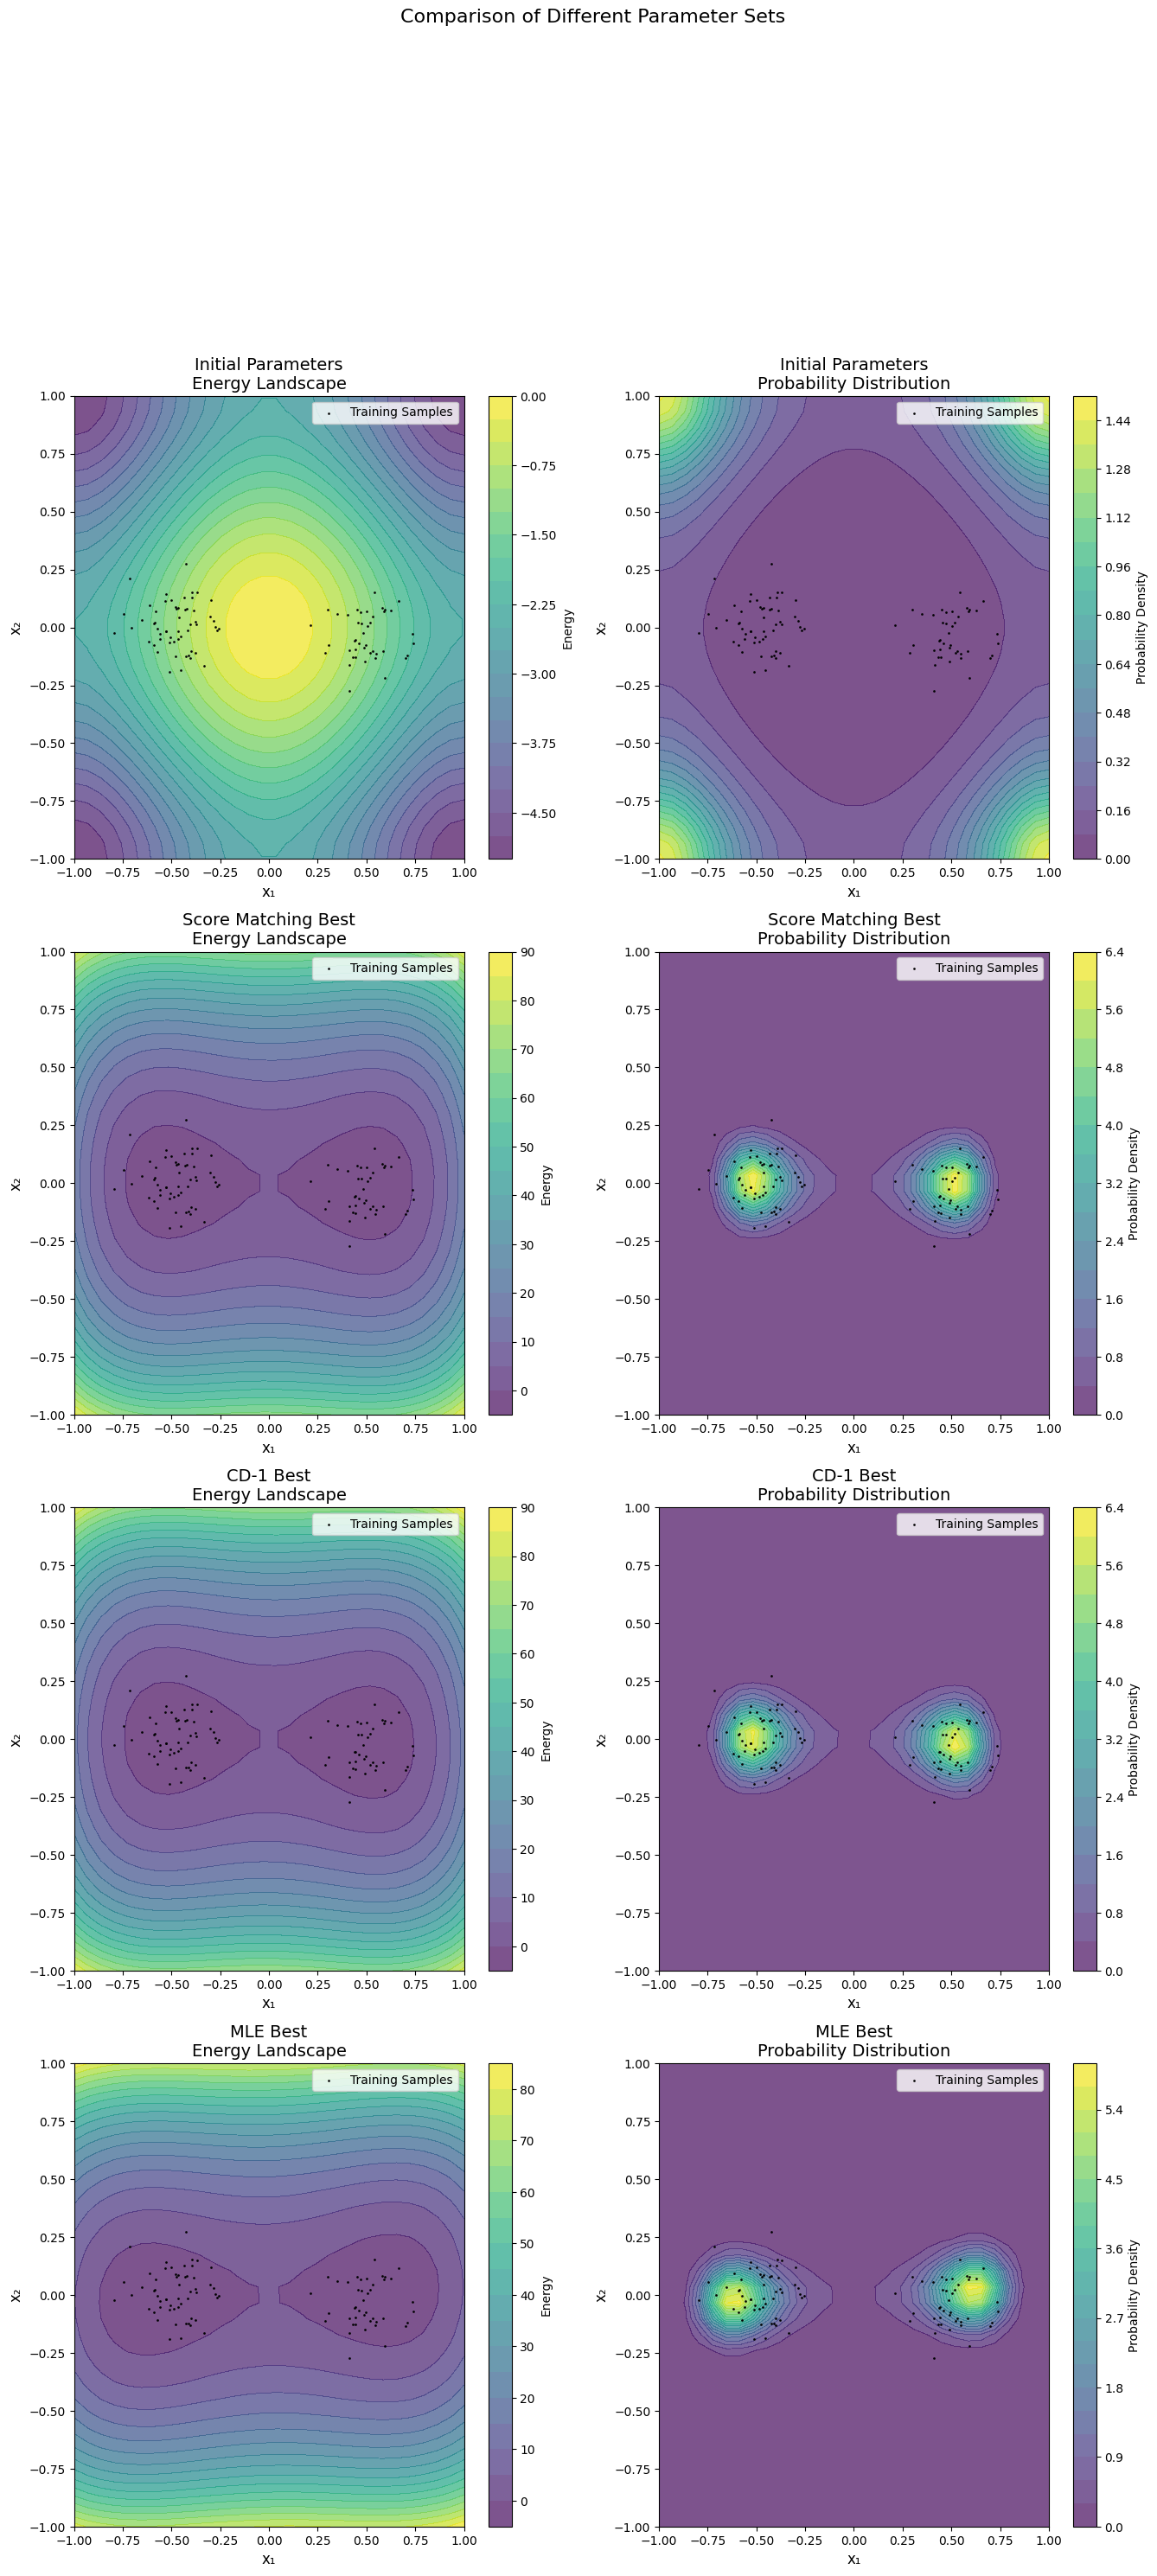

In [14]:
# Example usage:
param_list = [flattened_args_initial, flattened_args_best_sm, flattened_args_best_cd1, flattened_args_best_mle]
titles = ["Initial Parameters", "Score Matching Best", "CD-1 Best", "MLE Best"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples,
    x1_range=(-1, 1),    # optional
    x2_range=(-1, 1),    # optional
    n_points=30,        # optional
    titles=titles,       # optional
    figsize=None,    # optional
    fontsize=12,         # optional
    suptitle="Comparison of Different Parameter Sets"  # optional
)

### Run the SDE on one of the optimized energy landscape

In [15]:
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, flattened_args_best_sm, N_osc)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 10000)
dt0 = ts[1] - ts[0]
initial_state    = jnp.array([0.,0.])

solution = solve_SDE(drift_fn, diffusion_fn, initial_state, t0, t1, ts.shape[0], dt0)

sde_samples = solution.ys

Score Matching Best Energy  probability distribution total (should be ≈ 1): 1.000000


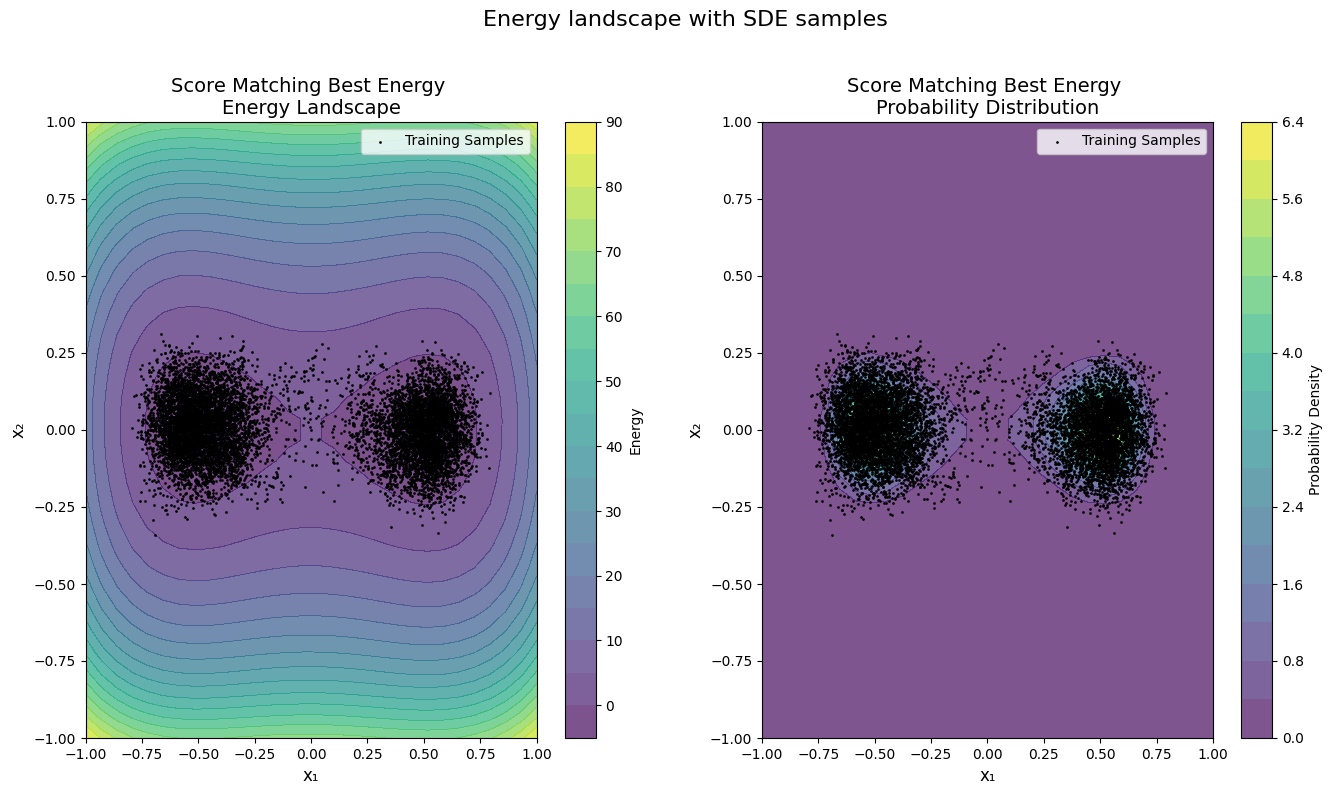

In [16]:
# Example usage:
param_list = [flattened_args_best_sm]
titles = ["Score Matching Best Energy "]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples,
    sample_stride=1,
    x1_range=(-1, 1),    # optional
    x2_range=(-1, 1),    # optional
    n_points=30,        # optional
    titles=titles,       # optional
    figsize=None,    # optional
    fontsize=12,         # optional
    suptitle="Energy landscape with SDE samples"  # optional
)